# Logistic Regression - No-Show Prediction Visualisation

This notebook provides comprehensive visualisations of the Logistic Regression model for barbershop no-show prediction. It covers:

1. **Class Distribution** - target variable balance
2. **Confusion Matrix** - prediction breakdown
3. **ROC Curve** - discriminative ability
4. **Precision-Recall Curve** - threshold trade-offs
5. **Feature Importance** - model coefficients
6. **Probability Distribution** - predicted probabilities by class
7. **Baseline vs Iteration 2 Comparison** - improvement summary

In [3]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
)

from src.data.generate import generate
from src.data.preprocess import preprocess
from src.utils.config import FEATURES, TARGET

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Imports loaded.')

Imports loaded.


## Data Preparation

In [4]:
df_raw = generate(n=1500, seed=42)
df = preprocess(df_raw, save=False)

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'No-show rate (train): {y_train.mean():.2%}')
print(f'No-show rate (test):  {y_test.mean():.2%}')

Train: 1200 rows  |  Test: 300 rows
No-show rate (train): 21.17%
No-show rate (test):  21.00%


## Train Model (with class_weight='balanced')

In [5]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]

# Find optimal threshold via precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = np.where(
    (precisions[:-1] + recalls[:-1]) > 0,
    2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),
    0,
)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

y_pred = (y_proba >= best_threshold).astype(int)

print(f'Optimal threshold: {best_threshold:.4f}')
print(f'Accuracy:          {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 (No-Show):      {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC:           {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Show', 'No-Show']))

Optimal threshold: 0.5073
Accuracy:          0.5833
F1 (No-Show):      0.3842
ROC-AUC:           0.5588

              precision    recall  f1-score   support

        Show       0.85      0.57      0.69       237
     No-Show       0.28      0.62      0.38        63

    accuracy                           0.58       300
   macro avg       0.56      0.60      0.53       300
weighted avg       0.73      0.58      0.62       300



C:\Users\aivanov\AppData\Local\Temp\ipykernel_8320\2933526841.py:14: RuntimeWarning: invalid value encountered in divide
  2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),


## 1. Class Distribution
Shows the balance between show and no-show appointments in the dataset.

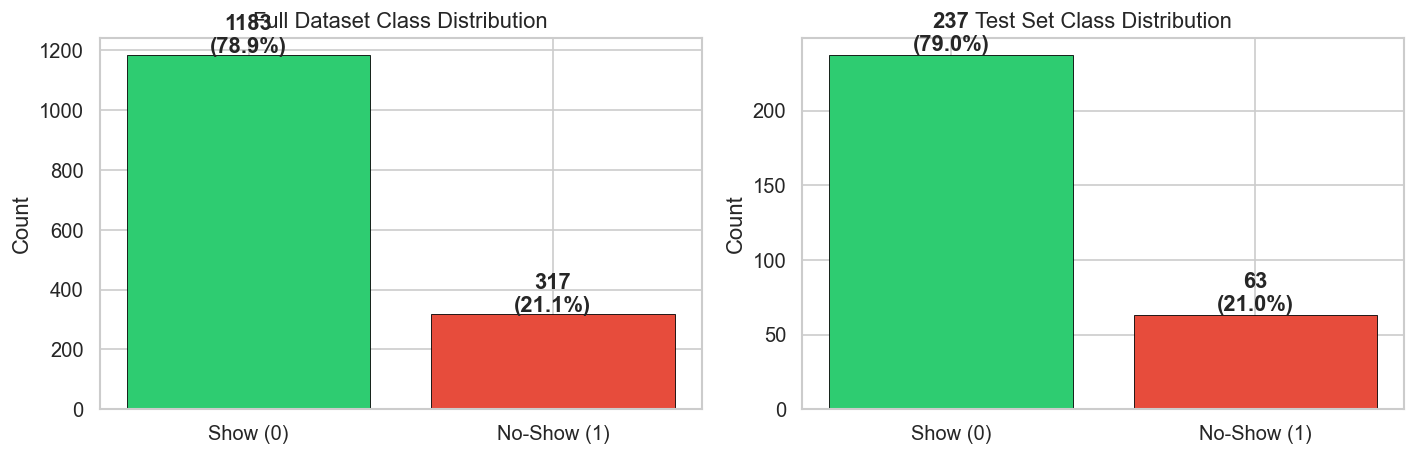

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full dataset
counts_full = y.value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Show (0)', 'No-Show (1)'], [counts_full[0], counts_full[1]], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Full Dataset Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts_full[0], counts_full[1]]):
    axes[0].text(i, v + 10, f'{v}\n({v/len(y):.1%})', ha='center', fontweight='bold')

# Test set
counts_test = y_test.value_counts()
axes[1].bar(['Show (0)', 'No-Show (1)'], [counts_test[0], counts_test[1]], color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Test Set Class Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate([counts_test[0], counts_test[1]]):
    axes[1].text(i, v + 3, f'{v}\n({v/len(y_test):.1%})', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Confusion Matrix
Shows how predictions break down into true/false positives and negatives.

- **TN (top-left):** correctly predicted Show
- **FP (top-right):** predicted No-Show but customer showed up (false alarm)
- **FN (bottom-left):** predicted Show but customer didn't show (missed no-show)
- **TP (bottom-right):** correctly predicted No-Show

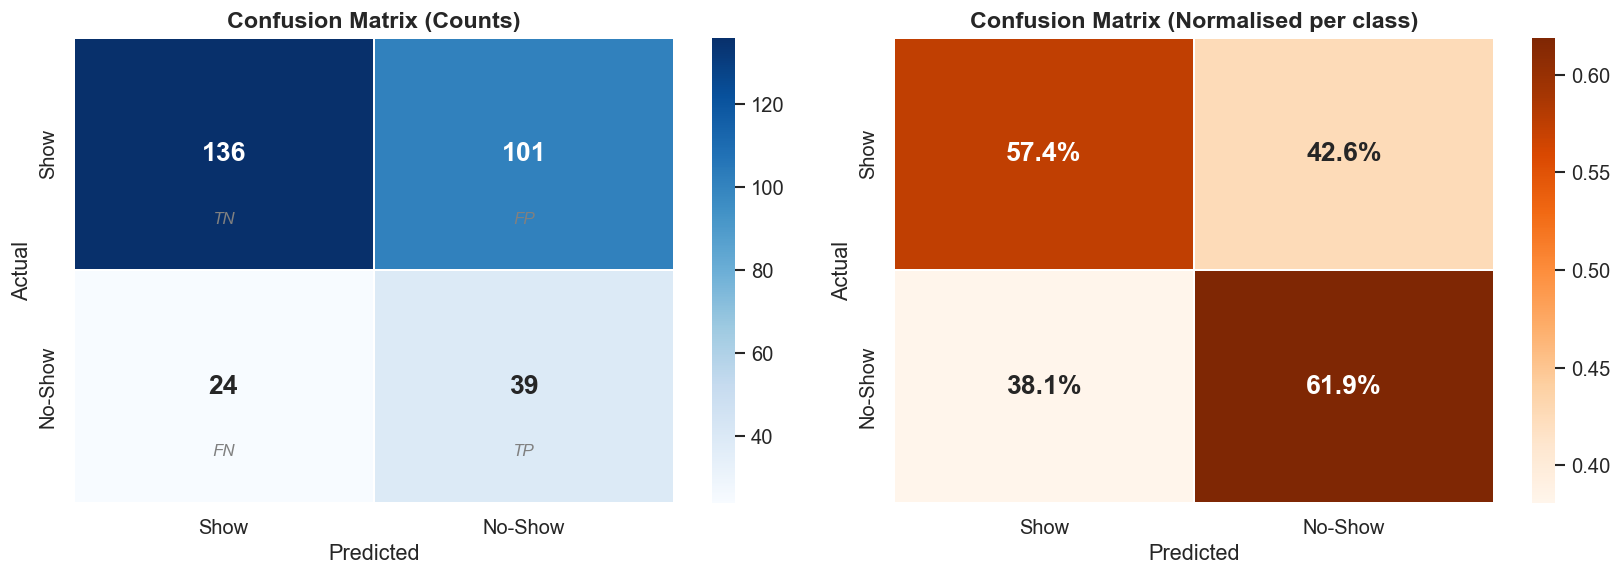

True Negatives (TN):  136  - correctly predicted Show
False Positives (FP): 101  - false alarm (predicted No-Show, actually Show)
False Negatives (FN): 24  - missed no-show (predicted Show, actually No-Show)
True Positives (TP):  39  - correctly predicted No-Show


In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Show', 'No-Show'],
    yticklabels=['Show', 'No-Show'],
    ax=axes[0], linewidths=1, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'}
)
axes[0].set_ylabel('Actual', fontsize=13)
axes[0].set_xlabel('Predicted', fontsize=13)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Annotate quadrants
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j + 0.5, i + 0.78, labels[i][j],
                     ha='center', va='center', fontsize=10, color='gray', style='italic')

# Normalised (percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.1%', cmap='Oranges',
    xticklabels=['Show', 'No-Show'],
    yticklabels=['Show', 'No-Show'],
    ax=axes[1], linewidths=1, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'}
)
axes[1].set_ylabel('Actual', fontsize=13)
axes[1].set_xlabel('Predicted', fontsize=13)
axes[1].set_title('Confusion Matrix (Normalised per class)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'True Negatives (TN):  {cm[0][0]}  - correctly predicted Show')
print(f'False Positives (FP): {cm[0][1]}  - false alarm (predicted No-Show, actually Show)')
print(f'False Negatives (FN): {cm[1][0]}  - missed no-show (predicted Show, actually No-Show)')
print(f'True Positives (TP):  {cm[1][1]}  - correctly predicted No-Show')


## 3. ROC Curve
The ROC curve plots True Positive Rate (Recall) vs False Positive Rate at various thresholds.

- **AUC = 1.0** means perfect discrimination
- **AUC = 0.5** means no better than random (dashed line)
- The closer the curve hugs the top-left corner, the better

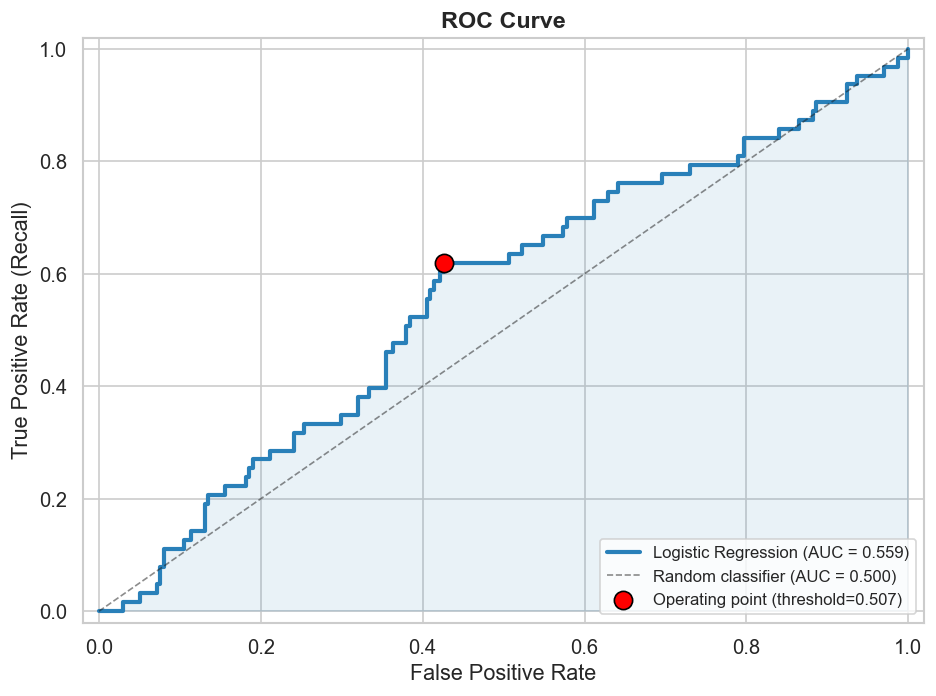

In [8]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'Logistic Regression (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random classifier (AUC = 0.500)')

ax.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')

# Mark the operating point (at our chosen threshold)
best_roc_idx = np.argmin(np.abs(roc_thresholds - best_threshold))
ax.scatter(fpr[best_roc_idx], tpr[best_roc_idx], s=120, c='red', zorder=5,
           label=f'Operating point (threshold={best_threshold:.3f})', edgecolors='black')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=13)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()

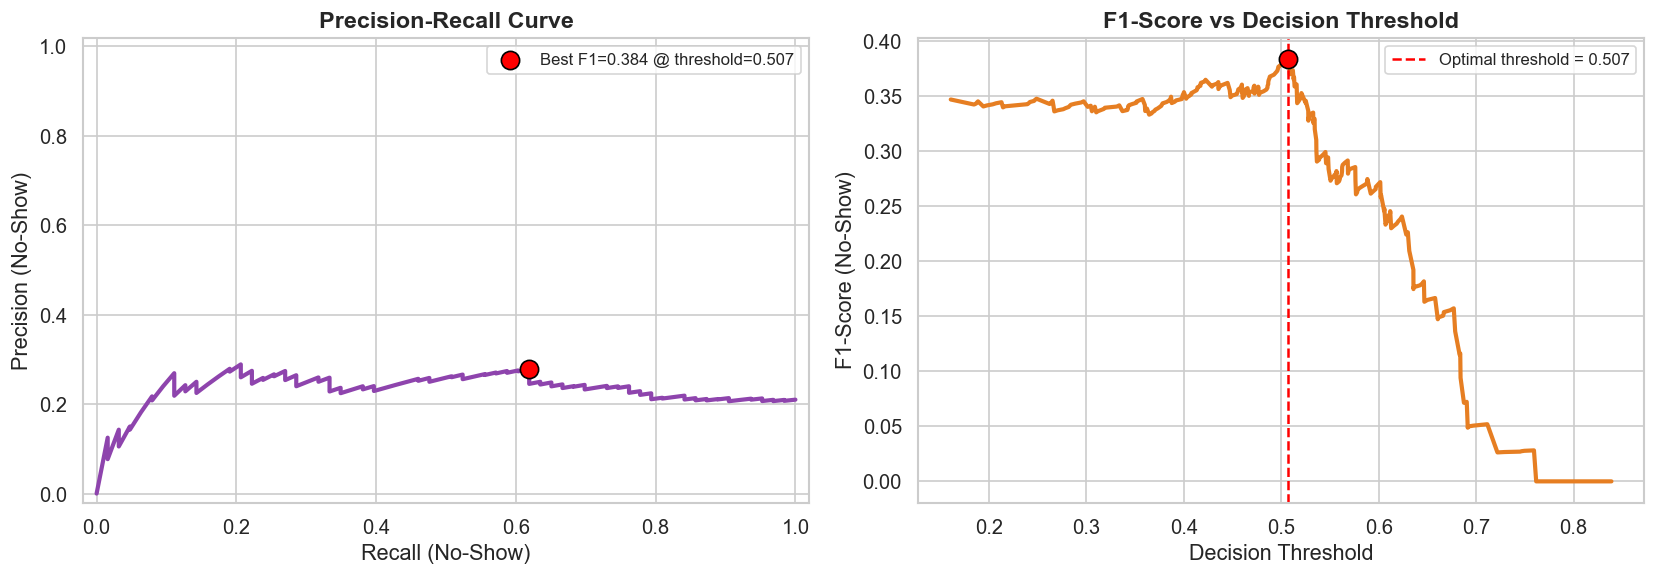

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
axes[0].plot(recalls[:-1], precisions[:-1], color='#8e44ad', lw=2.5)
axes[0].scatter(recalls[best_idx], precisions[best_idx], s=120, c='red', zorder=5,
                edgecolors='black', label=f'Best F1={f1_scores[best_idx]:.3f} @ threshold={best_threshold:.3f}')
axes[0].set_xlabel('Recall (No-Show)', fontsize=13)
axes[0].set_ylabel('Precision (No-Show)', fontsize=13)
axes[0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=10)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# F1-score vs threshold
axes[1].plot(thresholds, f1_scores, color='#e67e22', lw=2.5)
axes[1].axvline(x=best_threshold, color='red', ls='--', lw=1.5,
                label=f'Optimal threshold = {best_threshold:.3f}')
axes[1].scatter(best_threshold, f1_scores[best_idx], s=120, c='red', zorder=5, edgecolors='black')
axes[1].set_xlabel('Decision Threshold', fontsize=13)
axes[1].set_ylabel('F1-Score (No-Show)', fontsize=13)
axes[1].set_title('F1-Score vs Decision Threshold', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


## 5. Feature Importance (Model Coefficients)
Logistic Regression coefficients show how each feature influences the no-show prediction.

- **Positive coefficient** = increases no-show probability
- **Negative coefficient** = decreases no-show probability (protective)
- Larger absolute value = stronger influence

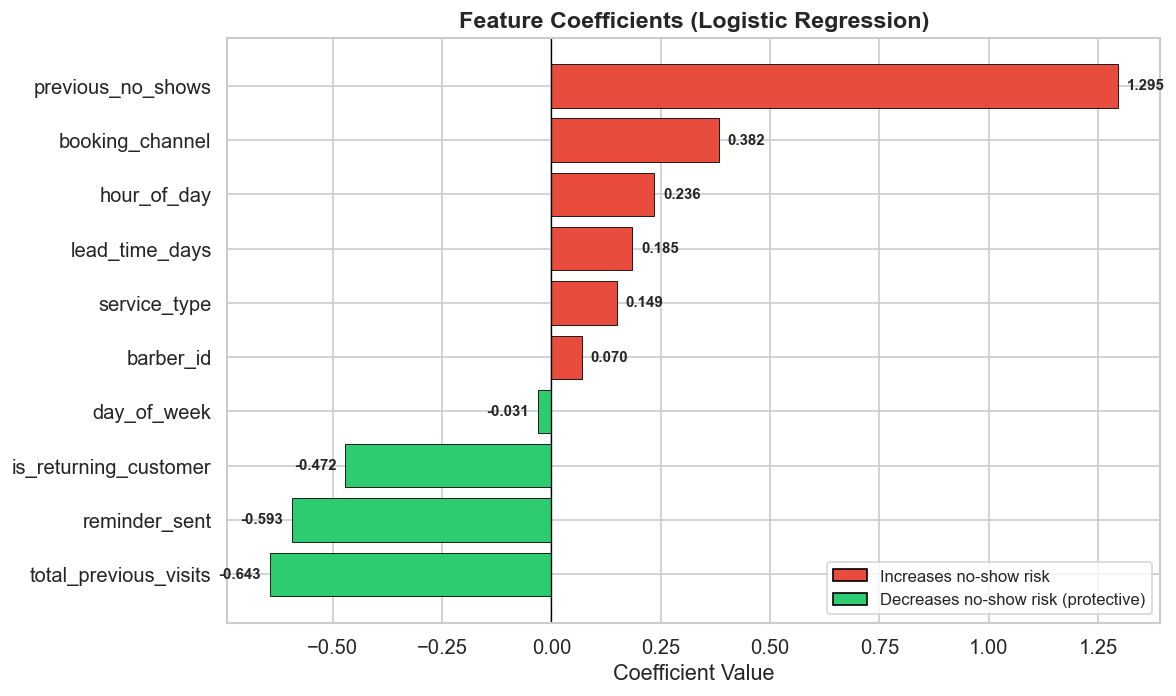


Top 3 risk factors (increase no-show):
  hour_of_day                    +0.236
  booking_channel                +0.382
  previous_no_shows              +1.295

Top 3 protective factors (decrease no-show):
  total_previous_visits          -0.643
  reminder_sent                  -0.593
  is_returning_customer          -0.472


In [10]:
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in coefs.values]
bars = ax.barh(coefs.index, coefs.values, color=colors, edgecolor='black', linewidth=0.5)

ax.axvline(x=0, color='black', lw=0.8)
ax.set_xlabel('Coefficient Value', fontsize=13)
ax.set_title('Feature Coefficients (Logistic Regression)', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, coefs.values):
    x_pos = val + 0.02 if val >= 0 else val - 0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', ha=ha, fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', edgecolor='black', label='Increases no-show risk'),
    Patch(facecolor='#2ecc71', edgecolor='black', label='Decreases no-show risk (protective)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print('\nTop 3 risk factors (increase no-show):')
for feat, val in coefs.tail(3).items():
    print(f'  {feat:30s} {val:+.3f}')

print('\nTop 3 protective factors (decrease no-show):')
for feat, val in coefs.head(3).items():
    print(f'  {feat:30s} {val:+.3f}')

## 6. Predicted Probability Distribution
Shows how the model distributes predicted no-show probabilities for each actual class.

- **Good separation** = the two distributions are far apart
- **Poor separation** = heavy overlap (hard for the model to distinguish)
- The vertical red line marks the decision threshold

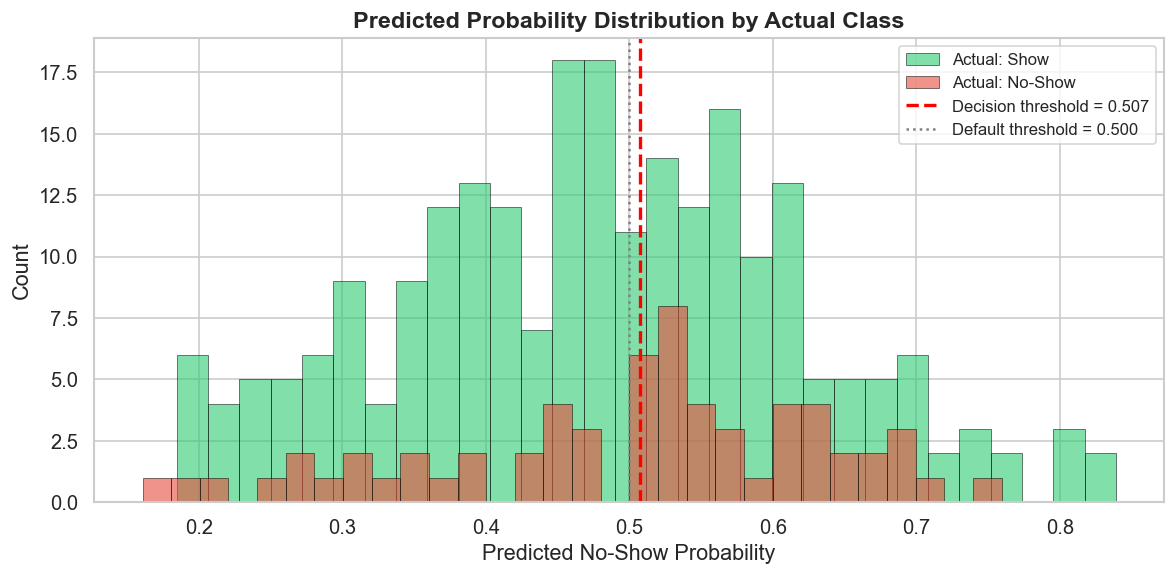

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(y_proba[y_test == 0], bins=30, alpha=0.6, color='#2ecc71',
        label='Actual: Show', edgecolor='black', linewidth=0.5)
ax.hist(y_proba[y_test == 1], bins=30, alpha=0.6, color='#e74c3c',
        label='Actual: No-Show', edgecolor='black', linewidth=0.5)

ax.axvline(x=best_threshold, color='red', ls='--', lw=2,
           label=f'Decision threshold = {best_threshold:.3f}')
ax.axvline(x=0.5, color='gray', ls=':', lw=1.5,
           label='Default threshold = 0.500')

ax.set_xlabel('Predicted No-Show Probability', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Predicted Probability Distribution by Actual Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 7. Precision, Recall, and F1 per Class
Side-by-side comparison of key metrics for both classes.

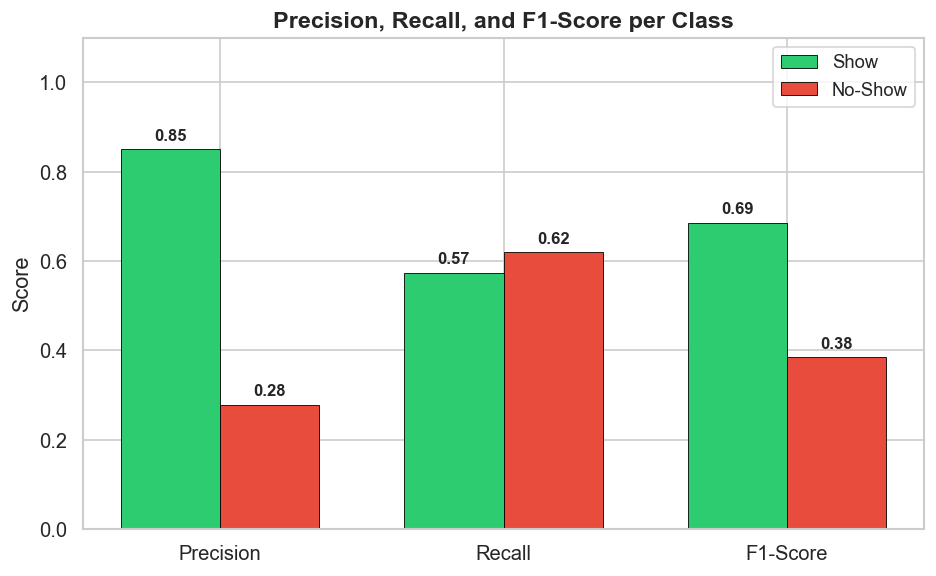

In [12]:
from sklearn.metrics import precision_score, recall_score

metrics_data = {
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Show': [
        precision_score(y_test, y_pred, pos_label=0),
        recall_score(y_test, y_pred, pos_label=0),
        f1_score(y_test, y_pred, pos_label=0),
    ],
    'No-Show': [
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
    ],
}
metrics_df = pd.DataFrame(metrics_data)

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(metrics_data['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, metrics_df['Show'], width, label='Show',
               color='#2ecc71', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, metrics_df['No-Show'], width, label='No-Show',
               color='#e74c3c', edgecolor='black', linewidth=0.5)

ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1-Score per Class', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_data['Metric'])
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Baseline vs Iteration 2 Comparison
Visual comparison of all key metrics between the first run (no tuning) and the improved model.

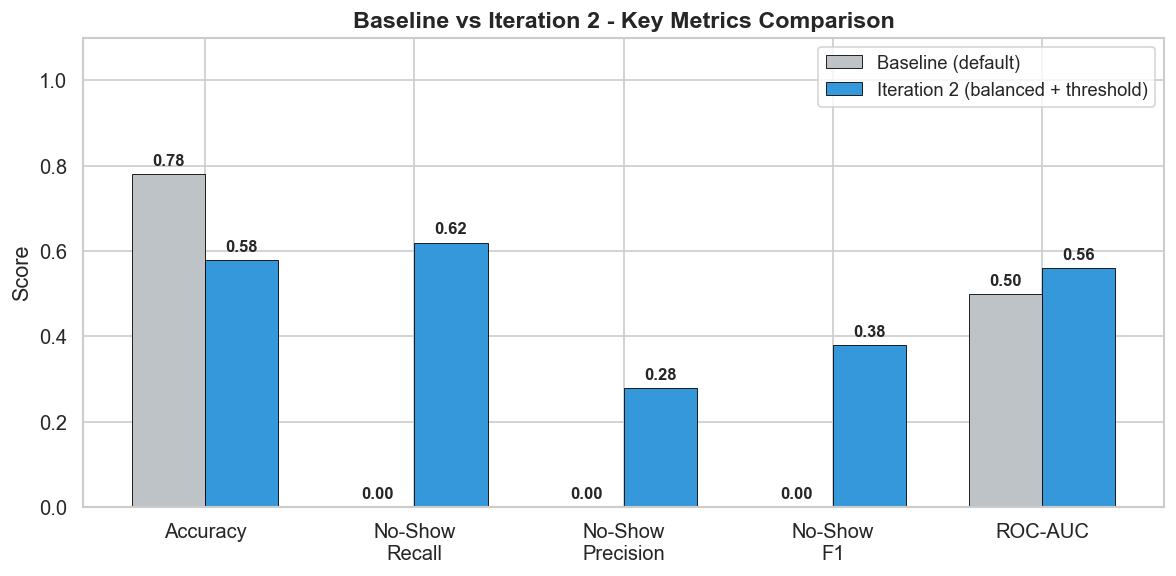

In [13]:
comparison = {
    'Metric': ['Accuracy', 'No-Show\nRecall', 'No-Show\nPrecision', 'No-Show\nF1', 'ROC-AUC'],
    'Baseline':    [0.78, 0.00, 0.00, 0.00, 0.50],
    'Iteration 2': [0.58, 0.62, 0.28, 0.38, 0.56],
}

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(comparison['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['Baseline'], width, label='Baseline (default)',
               color='#bdc3c7', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, comparison['Iteration 2'], width, label='Iteration 2 (balanced + threshold)',
               color='#3498db', edgecolor='black', linewidth=0.5)

ax.set_ylabel('Score', fontsize=13)
ax.set_title('Baseline vs Iteration 2 - Key Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Metric'])
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Confusion Matrix Comparison (Baseline vs Iteration 2)
Side-by-side confusion matrices showing how the prediction behaviour changed.

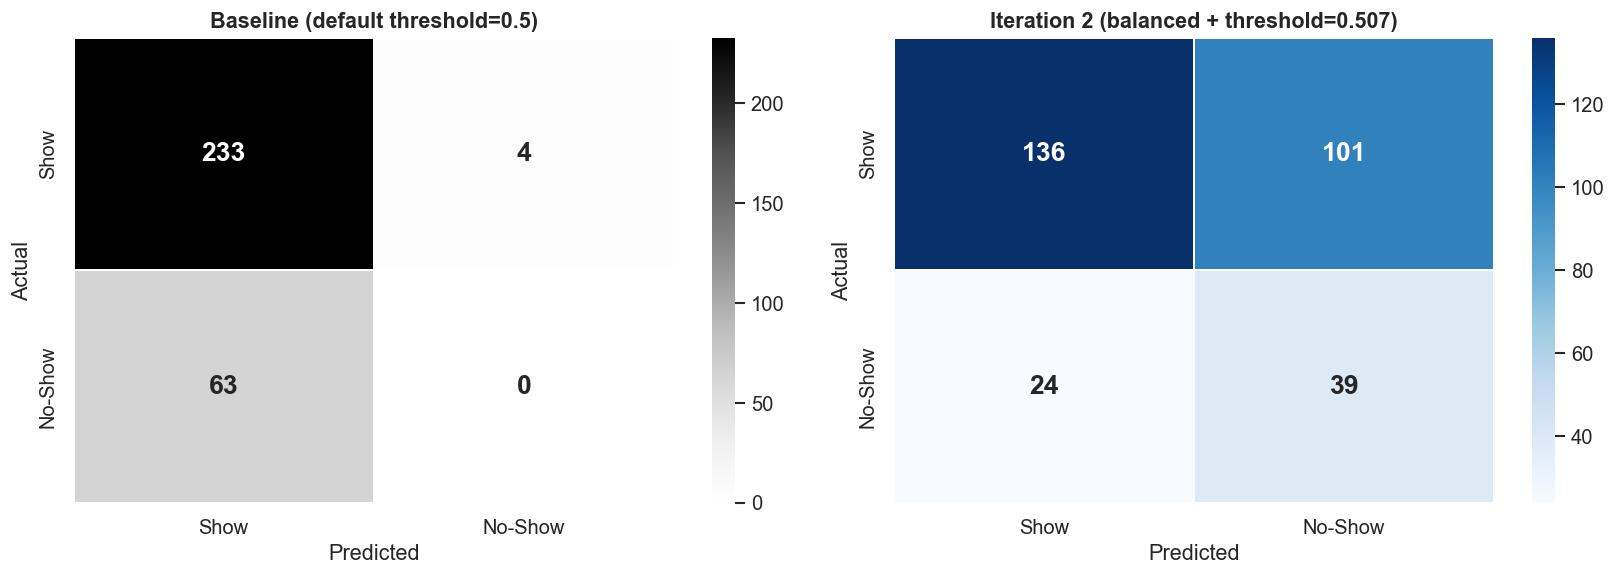

Key changes:
  True Positives:  0 -> 39  (no-shows caught)
  False Negatives: 63 -> 24  (missed no-shows)
  False Positives: 4 -> 101  (false alarms - low cost)


In [14]:
cm_baseline = np.array([[233, 4], [63, 0]])
cm_iter2 = cm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_baseline, annot=True, fmt='d', cmap='Greys',
    xticklabels=['Show', 'No-Show'],
    yticklabels=['Show', 'No-Show'],
    ax=axes[0], linewidths=1, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'}
)
axes[0].set_ylabel('Actual', fontsize=13)
axes[0].set_xlabel('Predicted', fontsize=13)
axes[0].set_title('Baseline (default threshold=0.5)', fontsize=13, fontweight='bold')

sns.heatmap(
    cm_iter2, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Show', 'No-Show'],
    yticklabels=['Show', 'No-Show'],
    ax=axes[1], linewidths=1, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'}
)
axes[1].set_ylabel('Actual', fontsize=13)
axes[1].set_xlabel('Predicted', fontsize=13)
axes[1].set_title(f'Iteration 2 (balanced + threshold={best_threshold:.3f})', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('Key changes:')
print(f'  True Positives:  {0} -> {cm_iter2[1][1]}  (no-shows caught)')
print(f'  False Negatives: {63} -> {cm_iter2[1][0]}  (missed no-shows)')
print(f'  False Positives: {4} -> {cm_iter2[0][1]}  (false alarms - low cost)')

## Summary

| Visualisation | Key Insight |
| --- | --- |
| Class Distribution | ~79% Show vs ~21% No-Show - imbalanced dataset |
| Confusion Matrix | Iteration 2 catches 39 no-shows (baseline caught 0) at the cost of more false alarms |
| ROC Curve | AUC ~0.56 - weak but real discriminative ability, room for improvement |
| Precision-Recall Curve | Optimal threshold found via F1 maximisation |
| Feature Importance | `previous_no_shows` is the dominant predictor; `reminder_sent` is the strongest protective factor |
| Probability Distribution | Heavy overlap between classes - model struggles to separate them clearly |
| Baseline vs Iteration 2 | Recall went from 0.00 to 0.62 - the critical improvement |